проверка корректности загрузки данных

In [ ]:
# импорт необходимых библиотек
import pandas as pd
import numpy as np

# загрузка данных
file_path = 'NVDA2.csv'

try:
    df = pd.read_csv(file_path, sep=';', parse_dates=['Date'], dayfirst=True)
    print("Данные успешно загружены!")
except FileNotFoundError:
    print(f"Файл не найден по пути: {file_path}")
    print("Пожалуйста, проверьте путь к файлу и запустите код снова.")
    exit()
except Exception as e:
    print(f"Ошибка при загрузке: {e}")
    exit()
# вывод первых строк
print("5 строк:")
print(df.head())
# получение общей информации
print("общая информация (info()):")
print(df.info())
print("размерность:")
print("="*50)
print(f"Количество строк (наблюдений): {df.shape[0]}")
print(f"Количество столбцов (признаков): {df.shape[1]}")
# преобразование столбца с датой
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    print("столбец преобразован")
    print(f"Новый индекс: {df.index.name}")
    print(f"Тип индекса: {type(df.index)}")
else:
    print("\nСтолбец 'Date' не найден в данных. Проверьте файл.")
print("3 строки после установки иедекса:")
print(df.head(3))
#  проверка пропущенных значений
print("пропущенное:")
print(df.isnull().sum())
#получение  описания числовых столбцов
print("описание данных:")
print(df.describe())
# проверка типов
print("Ттипы :")
print(df.dtypes)

Данные успешно загружены!
5 строк:
        Date     Close      High       Low      Open     Volume
0 2016-01-04  0.789588  0.794710  0.781538  0.787636  358076000
1 2016-01-05  0.802272  0.815688  0.792759  0.804467  490272000
2 2016-01-06  0.769098  0.792759  0.760073  0.789100  449344000
3 2016-01-07  0.738607  0.754950  0.728850  0.749828  645304000
4 2016-01-08  0.722752  0.748852  0.721289  0.748120  398472000
общая информация (info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2514 non-null   datetime64[ns]
 1   Close   2514 non-null   float64       
 2   High    2514 non-null   float64       
 3   Low     2514 non-null   float64       
 4   Open    2514 non-null   float64       
 5   Volume  2514 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 118.0 KB
None
размерность:
Количес

этап 2 Рисунок 1 - Визуализация исходных данных

Код загружает данные, преобразует Date в datetime и устанавливает его как индекс. Затем строит пять вертикальных подграфиков (Close, High, Low, Open, Volume), каждый с линейным графиком, заголовком, подписью оси Y и сеткой. На оси X выводятся метки с шагом в год . Визуализация позволяет оценить тренды, разброс значений и визуально обнаружить аномалии.



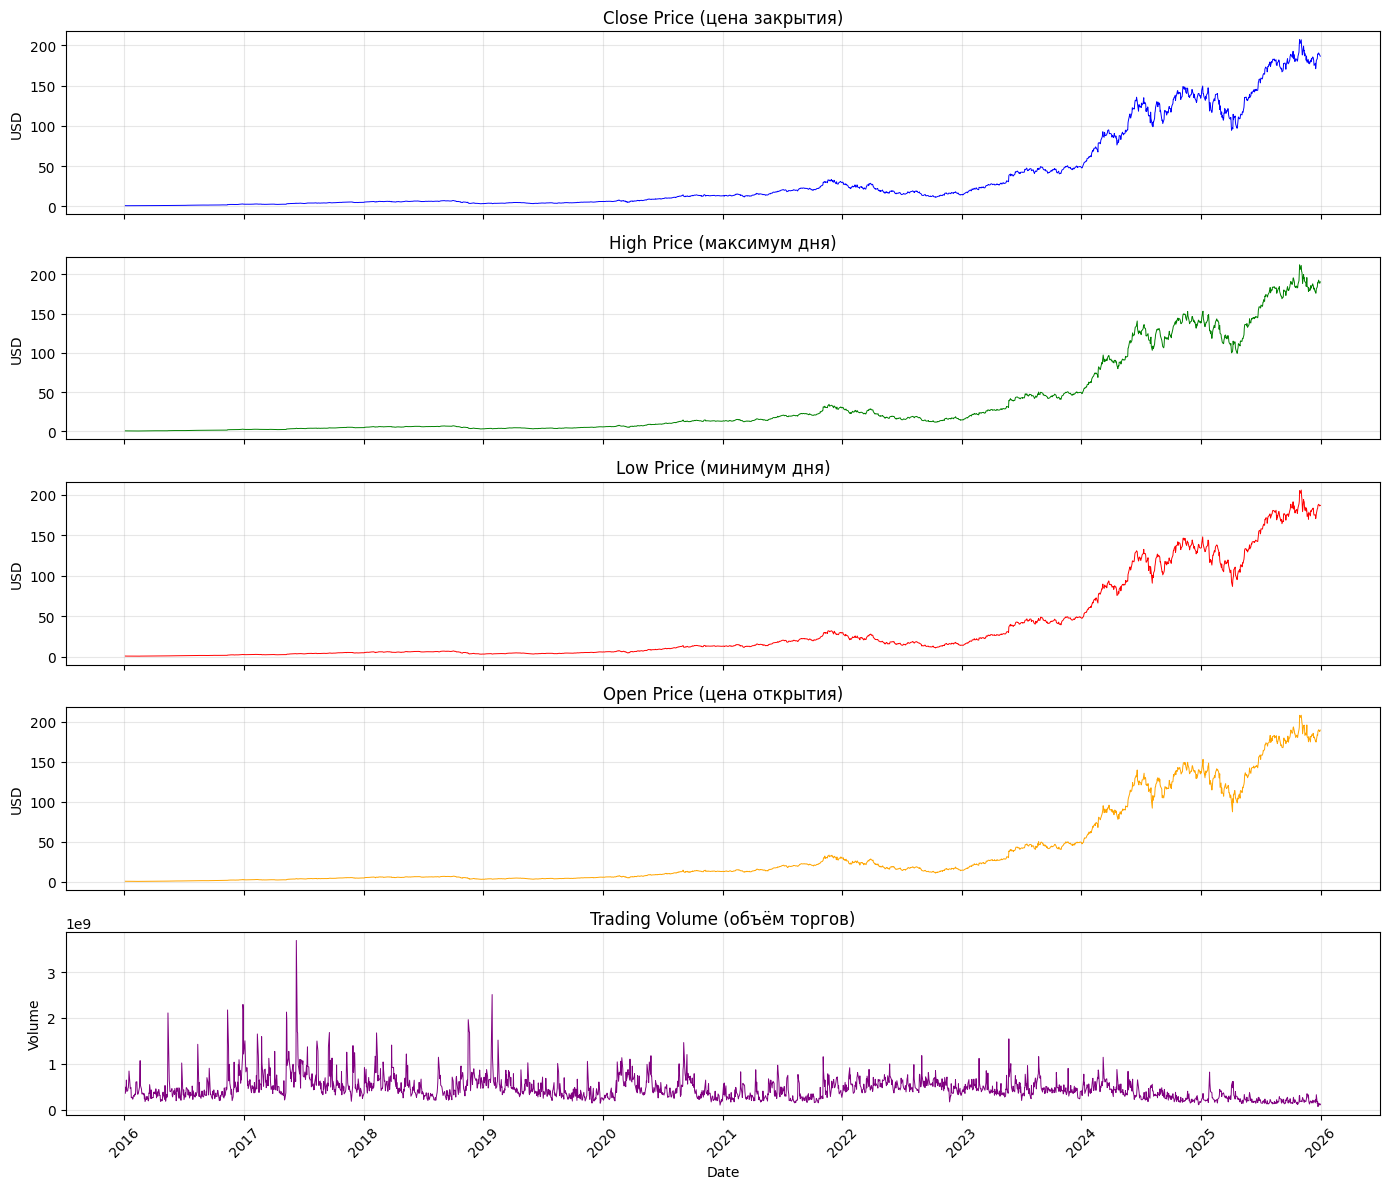

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv('NVDA2.csv', sep=';')
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y')
df.set_index('Date', inplace=True)

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 12), sharex=True)

axes[0].plot(df.index, df['Close'], color='blue', linewidth=0.7)
axes[0].set_ylabel('USD')
axes[0].set_title('Close Price (цена закрытия)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df.index, df['High'], color='green', linewidth=0.7)
axes[1].set_ylabel('USD')
axes[1].set_title('High Price (максимум дня)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df.index, df['Low'], color='red', linewidth=0.7)
axes[2].set_ylabel('USD')
axes[2].set_title('Low Price (минимум дня)')
axes[2].grid(True, alpha=0.3)

axes[3].plot(df.index, df['Open'], color='orange', linewidth=0.7)
axes[3].set_ylabel('USD')
axes[3].set_title('Open Price (цена открытия)')
axes[3].grid(True, alpha=0.3)

axes[4].plot(df.index, df['Volume'], color='purple', linewidth=0.7)
axes[4].set_ylabel('Volume')
axes[4].set_title('Trading Volume (объём торгов)')
axes[4].grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

этап 3  Рисунок 2 - Статистический анализ

Затем метод describe() вычисляет основные статистические характеристики для каждого числового канала (Close, High, Low, Open, Volume): количество ненулевых значений (count), среднее (mean), стандартное отклонение (std), минимум (min). Результат выводится в виде таблицы, которая позволяет оценить масштаб, разброс и асимметрию данных.

In [ ]:
import pandas as pd

# Загрузка данных
df = pd.read_csv('NVDA2.csv', sep=';')
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y')
df.set_index('Date', inplace=True)

# Статистические характеристики
print(df.describe())

             Close         High          Low         Open        Volume
count  2514.000000  2514.000000  2514.000000  2514.000000  2.514000e+03
mean     36.046162    36.655228    35.371764    36.050666  4.588549e+08
std      51.196066    51.999095    50.318365    51.238522  2.574472e+08
min       0.615181     0.623474     0.603716     0.604448  6.552850e+07
25%       4.468965     4.508291     4.393203     4.465957  2.925870e+08
50%      13.114014    13.341506    12.905294    13.100718  4.102030e+08
75%      41.709845    42.322450    40.784355    41.553440  5.596668e+08
max     207.028473   212.178195   205.548551   208.068415  3.692928e+09


этап 4 Рисунок 3 - Анализ пропусков и выбросов

 загружает данные, преобразует дату в индекс, вычисляет долю пропусков по каждому каналу (вывод в процентах), затем по правилу трёх сигм (отклонение от среднего более чем на 3 стандартных отклонения) подсчитывает количество выбросов для каждого канала. После этого строит точечные диаграммы для всех пяти каналов, чтобы визуально оценить разброс значений и расположение выбросов. Вывод: таблица с долей пропусков, список количества выбросов по каналам и пять точечных графиков.


Доля пропущенных значений (%):
Close     0.0
High      0.0
Low       0.0
Open      0.0
Volume    0.0
dtype: float64

Количество выбросов по правилу трёх сигм:
Close: 14 выбросов
High: 15 выбросов
Low: 19 выбросов
Open: 17 выбросов
Volume: 34 выбросов


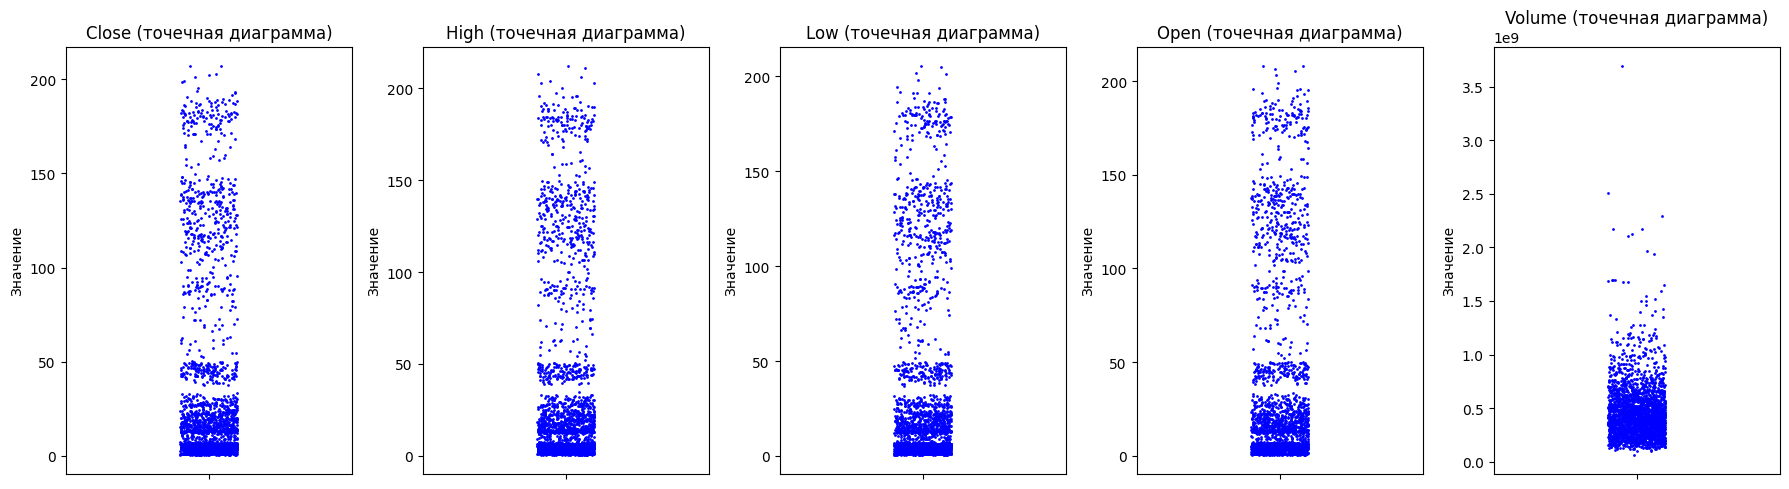

In [ ]:




import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('NVDA2.csv', sep=';')
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y')
df.set_index('Date', inplace=True)

print("Доля пропущенных значений (%):")
print(df.isnull().sum() / len(df) * 100)

print("\nКоличество выбросов по правилу трёх сигм:")
for col in df.columns:
    mean = df[col].mean()
    std = df[col].std()
    outliers = df[(df[col] - mean).abs() > 3 * std]
    print(f"{col}: {len(outliers)} выбросов")

df_plot = df.copy()

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(18, 5))

for i, col in enumerate(df_plot.columns):
    sns.stripplot(y=df_plot[col], ax=axes[i], color='blue', size=2, jitter=True)
    axes[i].set_title(f'{col} (точечная диаграмма)')
    axes[i].set_ylabel('Значение')

plt.tight_layout()
plt.show()

этап 5 Рисунок 4 - Анализ диапазонов значений

 загружает данные, преобразует дату в индекс, затем строит пять точечных диаграмм  — по одной для каждого канала (Close, High, Low, Open, Volume). На каждом графике точки случайным образом смещены по горизонтали (jitter=True) для уменьшения наложений. По вертикали отображаются значения канала, диапазон ограничен сверху. Графики расположены в один ряд, общий размер — 18×5 . Визуализация позволяет оценить плотность распределения значений и наглядно увидеть выбросы — точки, оторванные от основного облака.


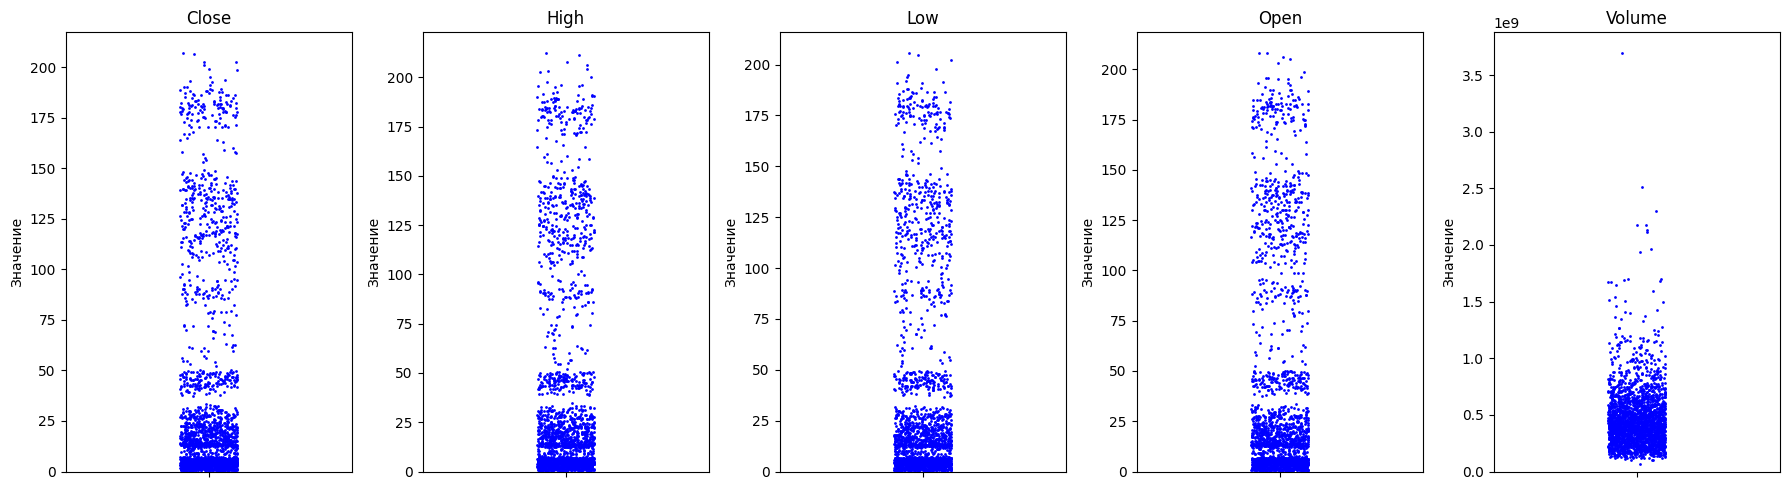

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('NVDA2.csv', sep=';')
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y')
df.set_index('Date', inplace=True)


fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(18, 5))

for i, col in enumerate(df.columns):
    sns.stripplot(y=df[col], ax=axes[i], color='blue', size=2, jitter=True)
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Значение')
    axes[i].set_ylim(0, df[col].max() * 1.05)
plt.tight_layout()
plt.show()

этап 6 Рисунок 6 - Корреляционный анализ

загружает данные, преобразует дату в индекс, затем вычисляет матрицу парных коэффициентов корреляции Пирсона между всеми каналами (Close, High, Low, Open, Volume) с помощью метода corr(). После этого строит тепловую карту (heatmap) , где на пересечении каналов отображается числовое значение корреляции (округлённое до двух знаков), красный — положительная, синий — отрицательная корреляция. Результат позволяет выявить дублирующие каналы (корреляция ~1,0) и каналы с уникальной информацией (низкая корреляция с остальными).

Матрица корреляции:
           Close      High       Low      Open    Volume
Close   1.000000  0.999790  0.999836  0.999583 -0.363942
High    0.999790  1.000000  0.999743  0.999846 -0.361537
Low     0.999836  0.999743  1.000000  0.999774 -0.365850
Open    0.999583  0.999846  0.999774  1.000000 -0.363263
Volume -0.363942 -0.361537 -0.365850 -0.363263  1.000000


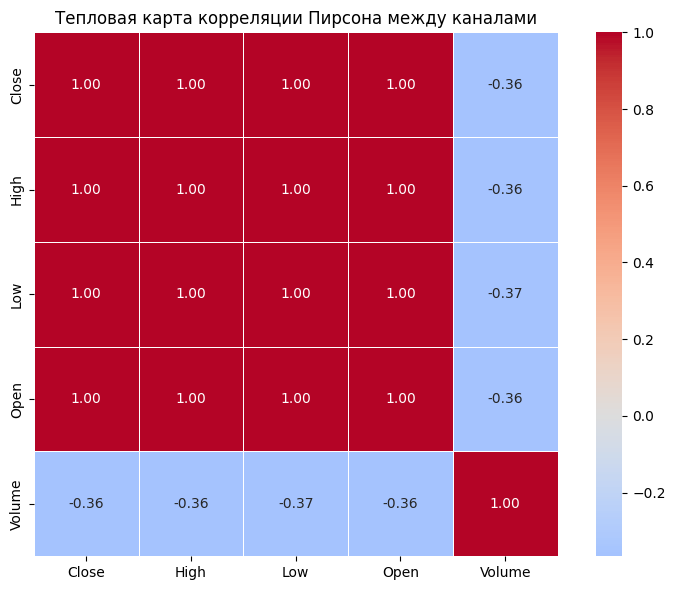

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('NVDA2.csv', sep=';')
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y')
df.set_index('Date', inplace=True)

corr_matrix = df.corr()
print("Матрица корреляции:")
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Тепловая карта корреляции Пирсона между каналами')
plt.tight_layout()
plt.show()

этап 7 рисунки 6,7,8

Строит четыре вертикальных графика: исходный ряд, тренд, сезонная компонента, остатки (шум). Дополнительно строит гистограмму распределения остатков для оценки характера шума (нормальное, тяжелые хвосты, асимметрия). Результат позволяет оценить качество данных и принять решение о необходимости фильтрации.

Отношение сигнал/шум (SNR): 15.60 дБ


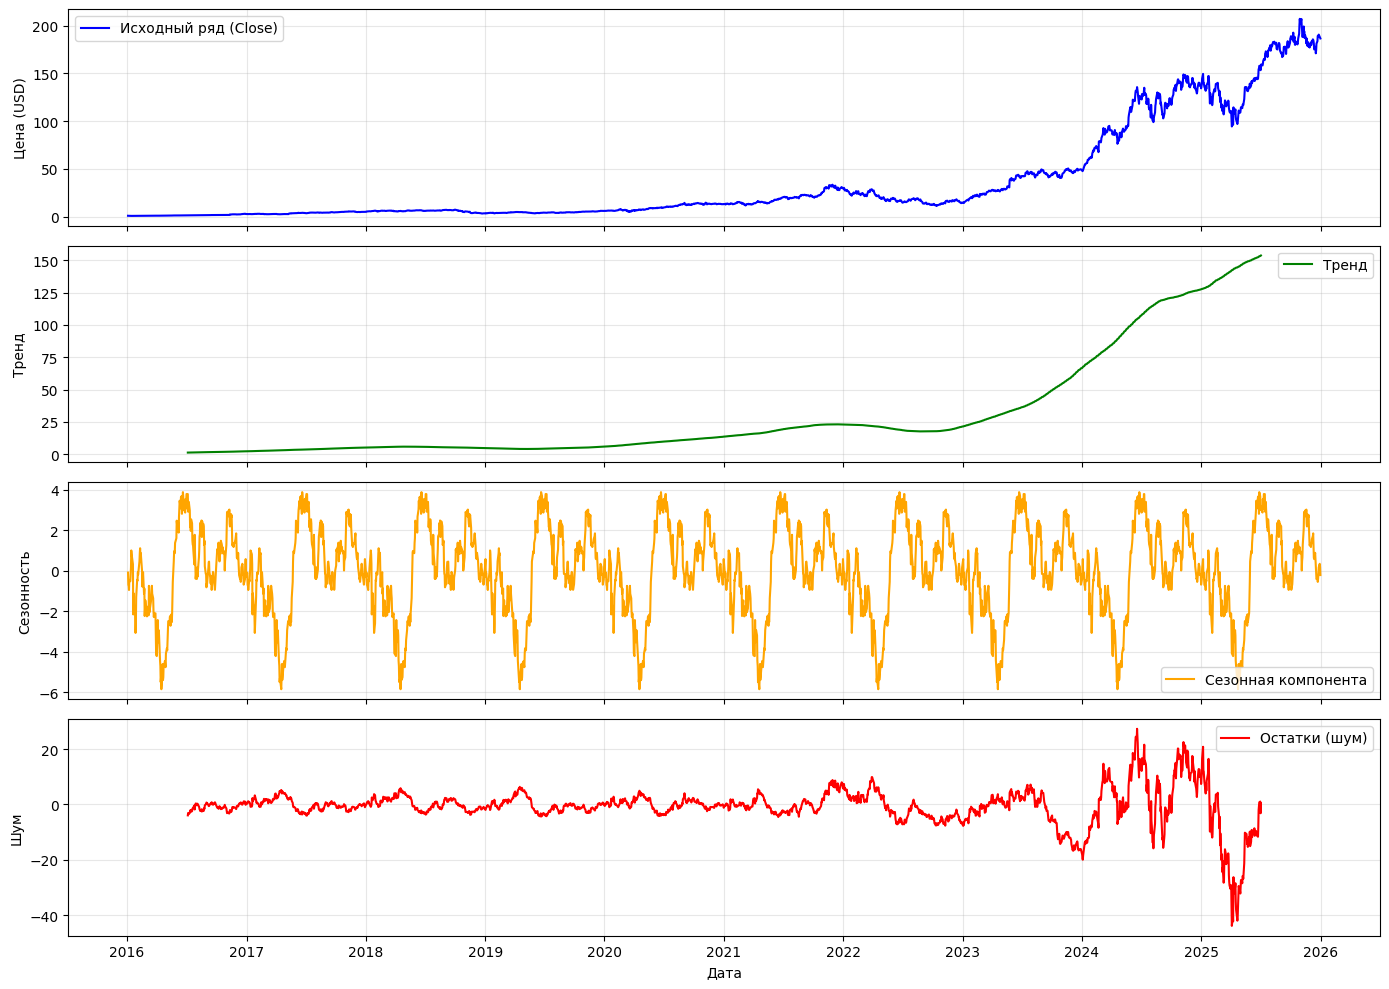

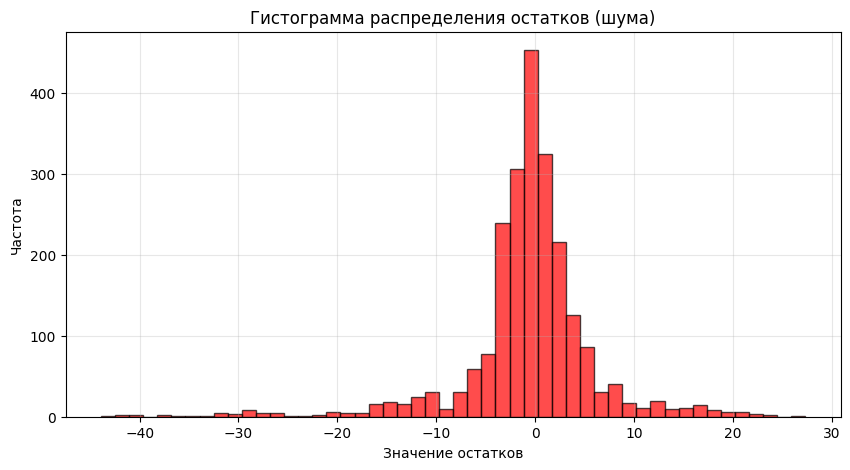

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Загрузка данных
df = pd.read_csv('NVDA2.csv', sep=';')
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y')
df.set_index('Date', inplace=True)

# Берём ряд Close (удаляем возможные пропуски, если есть)
series = df['Close'].dropna()

# Декомпозиция (аддитивная модель, период 252 — примерно год торговых дней)
decomposition = seasonal_decompose(series, model='additive', period=252)

# Выделяем компоненты
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Сигнал = тренд + сезонность (для аддитивной модели)
signal = trend + seasonal

# Убираем NaN (первые и последние значения могут быть неопределены)
valid_mask = ~(np.isnan(signal) | np.isnan(residual))
signal_clean = signal[valid_mask]
residual_clean = residual[valid_mask]

# SNR
snr = 10 * np.log10(np.var(signal_clean) / np.var(residual_clean))
print(f"Отношение сигнал/шум (SNR): {snr:.2f} дБ")

# Визуализация декомпозиции
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(series, label='Исходный ряд (Close)', color='blue')
axes[0].set_ylabel('Цена (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(trend, label='Тренд', color='green')
axes[1].set_ylabel('Тренд')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(seasonal, label='Сезонная компонента', color='orange')
axes[2].set_ylabel('Сезонность')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(residual, label='Остатки (шум)', color='red')
axes[3].set_ylabel('Шум')
axes[3].set_xlabel('Дата')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Гистограмма распределения остатков
plt.figure(figsize=(10, 5))
plt.hist(residual.dropna(), bins=50, color='red', alpha=0.7, edgecolor='black')
plt.title('Гистограмма распределения остатков (шума)')
plt.xlabel('Значение остатков')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.show()